# India Air Quality Analysis

## Annotation

This project studies air quality measurements from different cities and states in country with worlds`s deadliest air pollution - India. The project focuses on understanding general pollution patterns and exploring how different air pollution indicators vary across the different districts and time periods.

The work was completed individually by Shilov Vladimir 257-1.

GitHub: https://github.com/tetherer/India-air-quality-analysis

Links for dataset:

Yandex disk: https://disk.360.yandex.ru/d/S0eCRTnC_JXDBQ

Kaggle: https://www.kaggle.com/datasets/shrutibhargava94/india-air-quality-data

In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df_raw = pd.read_csv("data.csv",
                 encoding="latin1",
                 low_memory=False,
                 na_values=["NA", "", "NaN"])

df_raw.head()

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


## Dataset Description

The dataset used in this project is the **India Air Quality Data** [dataset from Kaggle](https://www.kaggle.com/datasets/shrutibhargava94/india-air-quality-data). It contains historical air quality
  measurements from different Indian states and cities. This data is combined from Historical Daily Ambient Air Quality Data released by the Ministry of Environment and Forests and Central Pollution Control Board of India under the National Data Sharing and Accessibility Policy (**NDSAP**).

In [153]:
print(f"(Rows, columns) : {df_raw.shape}")

(Rows, columns) : (435742, 13)


The dataset contains **435,742 observations** and **13 fields**

In [154]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 435742 entries, 0 to 435741
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   stn_code                     291665 non-null  str    
 1   sampling_date                435739 non-null  str    
 2   state                        435742 non-null  str    
 3   location                     435739 non-null  str    
 4   agency                       286261 non-null  str    
 5   type                         430349 non-null  str    
 6   so2                          401096 non-null  float64
 7   no2                          419509 non-null  float64
 8   rspm                         395520 non-null  float64
 9   spm                          198355 non-null  float64
 10  location_monitoring_station  408251 non-null  str    
 11  pm2_5                        9314 non-null    float64
 12  date                         435735 non-null  str    
dtypes: float64

| Column | Type              | Description |
|---|-------------------|---|
| `stn_code` | str               | Station code |
| `sampling_date` | str               | Date in text format (e.g., `February - M021990`) |
| `state` | str               | State of India |
| `location` | str               | City / locality |
| `agency` | str               | Monitoring agency |
| `type` | str               | Zone type (residential, industrial, etc.) |
| `so2` | float64                | Sulfur dioxide – pungent, toxic gas from burning coal/oil (industries, power plants) |
| `no2` | float64           | Nitrogen dioxide – reddish-brown gas from high-temperature combustion (vehicles, power plants) |
| `rspm` | float64           | PM₁₀ – inhalable coarse particles from dust, industry, construction |
| `spm` | float64           | Total suspended particles – larger dust/soot from natural & man-made sources (soil, smoke) |
| `location_monitoring_station` | str               | Name of the monitoring station |
| `pm2_5` | float64           | PM₂.₅ – fine particles from combustion (vehicle exhaust, factories, fires) |
| `date` | str               | Date in YYYY-MM-DD format |

**Numeric fields: 5** (so2, no2, rspm, spm, pm2_5)

The `date` column has an incorrect data type — it is stored as `str` and will be parsed to `datetime` during cleanup. `stn_code` is a station identifier and will remain as a string.

Missing values vary significantly across columns. `so2`, `no2`, and `rspm` have relatively low missing rates (under 10%), making them reliable for the main analysis. `spm` is missing in 54% of rows, so it will be used with caution. `pm2_5` is missing in 98% of rows and will `not` be used as a primary field. `stn_code` and `agency` are also missing in roughly a third of rows.

The `date` column is stored as `str` with only 7 missing values, so it needs to be converted to a datetime type before use. The `type` column has 10 unique values despite representing only a few real area categories, which indicates inconsistent labeling that will need to be normalized during data cleanup.

In [155]:
df_raw["type"].value_counts(dropna=False)

type
Residential, Rural and other Areas    179014
Industrial Area                        96091
Residential and others                 86791
Industrial Areas                       51747
Sensitive Area                          8980
Sensitive Areas                         5536
NaN                                     5393
RIRUO                                   1304
Sensitive                                495
Industrial                               233
Residential                              158
Name: count, dtype: int64

The `type` column contains 11 distinct values, but many of them represent
the same concept written differently. For example, "Industrial", "Industrial Area"
and "Industrial Areas" all describe the same zone type. The same problem exists
for residential and sensitive categories. There are also 5,393 missing values
and one unclear entry "RIRUO". This inconsistency will be fixed in the Data Cleanup section by mapping values into four categories: `Industrial`, `Residential`, `Sensitive`, and `Other` (for unrecognised entries such as "RIRUO"). Rows with a missing `type` will remain in the dataset but are excluded from zone-based comparisons.

## Descriptive statistics



In [156]:
df_stats = df_raw.copy()

main_numeric_cols = ["so2", "no2", "rspm", "spm"]

for col in main_numeric_cols:
    df_stats[col] = pd.to_numeric(
        df_stats[col], errors="coerce"
    )

descriptive_stats = df_stats[main_numeric_cols].agg(["count", "mean", "median", "std", "min", "max"]).T.round(2)

descriptive_stats

,count,mean,median,std,min,max
so2,401096.0,10.83,8.0,11.18,0.0,909.00
no2,419509.0,25.81,22.0,18.50,0.0,876.00
rspm,395520.0,108.83,90.0,74.87,0.0,6307.03
spm,198355.0,220.78,187.0,151.40,0.0,3380.00


For all 4 fields, the mean is higher than the median, which means the distributions
are right-skewed — most values are low, but some extreme outliers pull the mean up.
For example, RSPM has a median of 90 but a maximum of 6307.

`spm` has only ~198,000 valid values out of 435,000 rows (45%), so it is less reliable
than the other three fields.

## Data Cleanup

In [157]:
df = df_raw.copy() # new df for cleaned data

# Convert main pollutant columns to numeric
main_numeric_cols = ["so2", "no2", "rspm", "spm"]
for col in main_numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
print(f"Numeric column dtypes:\n{df[main_numeric_cols].dtypes}")

Numeric column dtypes:
so2     float64
no2     float64
rspm    float64
spm     float64
dtype: object


In [158]:
# Transforming date column to datetime format
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(f"Date dtype: {df['date'].dtype}")
print(f"Missing dates: {df['date'].isna().sum()}")
print(f"Min date: {df['date'].min()}")
print(f"Max date: {df['date'].max()}")

Date dtype: datetime64[us]
Missing dates: 7
Min date: 1987-01-01 00:00:00
Max date: 2015-12-31 00:00:00


In [159]:
# Removing spaces in text columns
text_cols = ["state", "location", "agency", "type", "location_monitoring_station"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

print(f"Area type value counts before cleanup:\n{df['type'].value_counts(dropna=False)}")

Area type value counts before cleanup:
type
Residential, Rural and other Areas    179014
Industrial Area                        96091
Residential and others                 86791
Industrial Areas                       51747
Sensitive Area                          8980
Sensitive Areas                         5536
NaN                                     5393
RIRUO                                   1304
Sensitive                                495
Industrial                               233
Residential                              158
Name: count, dtype: int64


In [160]:
# Now lets convert similar type of districts in `type` column to single type

def clean_area_type(value):
    if pd.isna(value):
        return None

    value = value.strip().lower()

    if "industrial" in value:
        return "Industrial"
    if "residential" in value or "rural" in value or "other" in value:
        return "Residential"
    if "sensitive" in value:
        return "Sensitive"

    return "Other"

df["type_clean"] = df["type"].apply(clean_area_type)
print(f"Area type value counts after cleanup:\n{df['type_clean'].value_counts(dropna=False)}")


Area type value counts after cleanup:
type_clean
Residential    265963
Industrial     148071
Sensitive       15011
NaN              5393
Other            1304
Name: count, dtype: int64


In [161]:
rows_before = len(df)
print(f"Rows before NaN removal: {rows_before}")

# Remove rows where date is missing
df = df.dropna(subset=["date"])

# Remove rows where ALL three main pollutants are NaN simultaneously
# (completely uninformative — no measurement recorded at all)
df = df.dropna(subset=["so2", "no2", "rspm"], how="all")

rows_after = len(df)
rows_removed = rows_before - rows_after
print(f"Rows after NaN removal: {rows_after}")
print(f"Rows removed: {rows_removed}")
print(f"Removed: {round(rows_removed / rows_before * 100, 2)}%")

Rows before NaN removal: 435742
Rows after NaN removal: 431454
Rows removed: 4288
Removed: 0.98%


In [162]:
# Final data quality check after all cleanup steps
print("Remaining NaN per pollutant column:")
print(df[["so2", "no2", "rspm", "spm"]].isna().sum())

dupes = df.duplicated().sum()
print(f"\nDuplicate rows found: {dupes}")
df = df.drop_duplicates()
print(f"Rows after removing duplicates: {len(df)}")

Remaining NaN per pollutant column:
so2      30362
no2      11949
rspm     35938
spm     234656
dtype: int64

Duplicate rows found: 668
Rows after removing duplicates: 430786


The cleanup steps above:
- **Type fixes**: pollutant columns confirmed as `float64`; `date` parsed to `datetime`. `stn_code` is kept as a string — it is a station identifier, not a numeric measure.
- **Text normalisation**: leading/trailing whitespace stripped in all text columns; `type` values mapped to four categories (`Industrial`, `Residential`, `Sensitive`, `Other`). Rows with missing `type` remain in the dataset and are excluded from zone-based comparisons.
- **NaN removal**: rows where `date` was missing (7 rows) and rows where `so2`, `no2`, and `rspm` were all `NaN` simultaneously were dropped. Individual pollutant columns still contain NaN where a measurement was not recorded — these are handled per-column by `pandas` during statistics and plotting.
- **Duplicates**: 668 fully duplicate rows were identified and removed.

## Plots

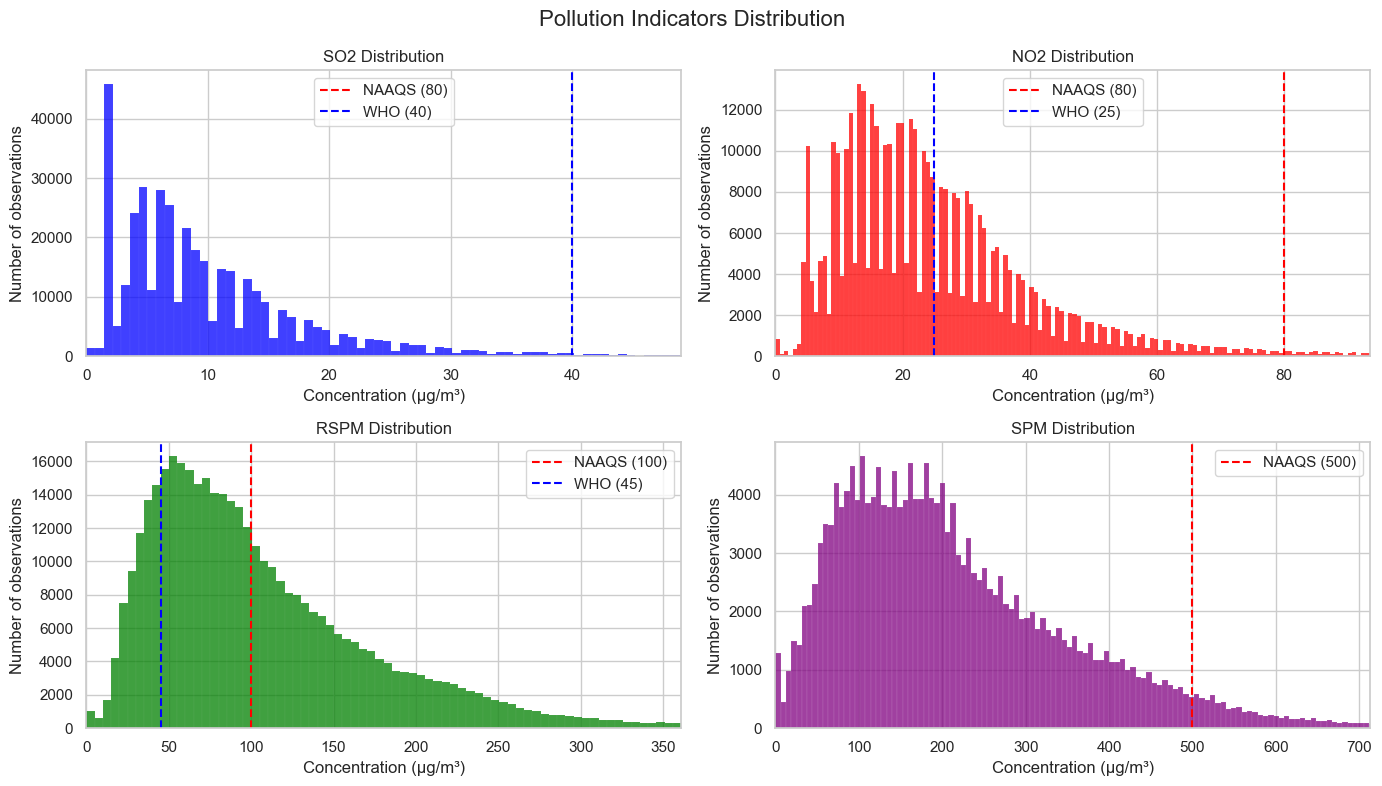

In [163]:
pollutants = [
    {"col": "so2",  "color": "blue",   "naaqs": 80,  "who": 40},
    {"col": "no2",  "color": "red",    "naaqs": 80,  "who": 25},
    {"col": "rspm", "color": "green",  "naaqs": 100, "who": 45},
    {"col": "spm",  "color": "purple", "naaqs": 500, "who": None},
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i in range(len(pollutants)):
    ax = axes.flatten()[i]
    p = pollutants[i]

    sns.histplot(data=df, x=p["col"], ax=ax, color=p["color"])

    ax.axvline(p["naaqs"], color="red",  linestyle="--", linewidth=1.5, label=f"NAAQS ({p['naaqs']})")
    if p["who"] is not None:
        ax.axvline(p["who"], color="blue", linestyle="--", linewidth=1.5, label=f"WHO ({p['who']})")

    ax.set_xlim(0, df[p["col"]].quantile(0.99))
    ax.set_title(f"{p['col'].upper()} Distribution")
    ax.set_xlabel("Concentration (µg/m³)")
    ax.set_ylabel("Number of observations")
    ax.legend()

plt.suptitle("Pollution Indicators Distribution", fontsize=16)
plt.tight_layout()
plt.show()

All four indicators show a right-skewed distribution — most measurements are low, but rare extreme values pull the mean above the median. SO₂ and NO₂ are concentrated below 30 µg/m³, while RSPM and SPM spread much wider.

RSPM exceeds both the NAAQS limit (100 µg/m³) and the WHO guideline (45 µg/m³) in a large share of observations — its median of 90 µg/m³ is already above the WHO threshold. SPM has no WHO reference guideline; only about 5% of its values exceed the NAAQS limit (500 µg/m³). NO₂ stays mostly below NAAQS but frequently crosses the stricter WHO threshold (25 µg/m³). SO₂ stays below both limits in the vast majority of observations.

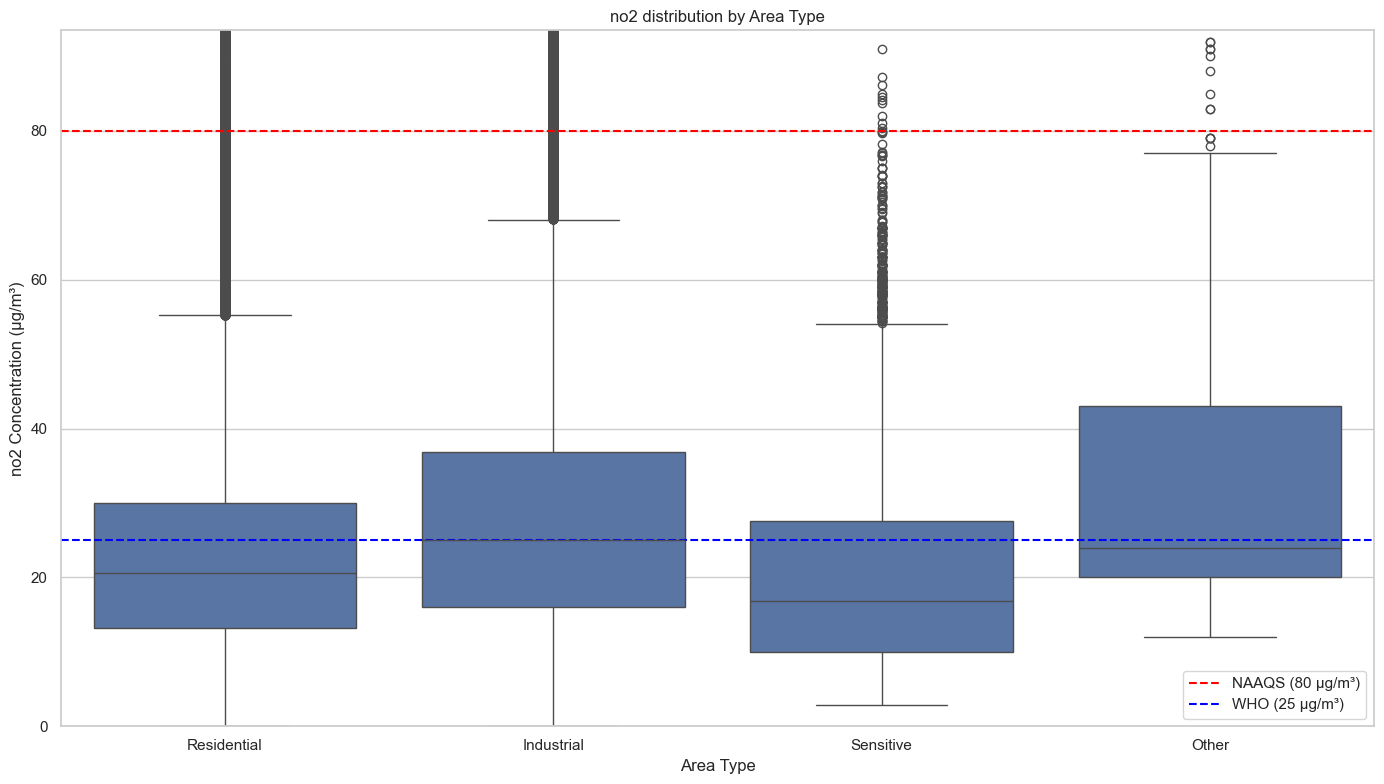

In [164]:
fig, ax = plt.subplots(figsize=(14, 8))

sns.boxplot(data=df, x="type_clean", y="no2", ax=ax)

ax.set_ylim(0, df["no2"].quantile(0.99))


# NAAQS - National Ambient Air Quality Standards (India)
ax.axhline(80, color="red",  linestyle="--", linewidth=1.5, label="NAAQS (80 µg/m³)")

# WHO - World Health Organization standarts
ax.axhline(25, color="blue", linestyle="--", linewidth=1.5, label="WHO (25 µg/m³)")

ax.legend()

ax.set_title("no2 distribution by Area Type")

ax.set_ylabel("no2 Concentration (µg/m³)")
ax.set_xlabel("Area Type")

plt.tight_layout()
plt.show()

Industrial areas have higher NO₂ levels than residential and sensitive zones — their median is visibly above the WHO guideline (25 µg/m³). The upper quartile of industrial zones reaches approximately 37 µg/m³, well below the NAAQS limit of 80 µg/m³. Residential and sensitive areas have lower medians and stay on average below the WHO threshold.

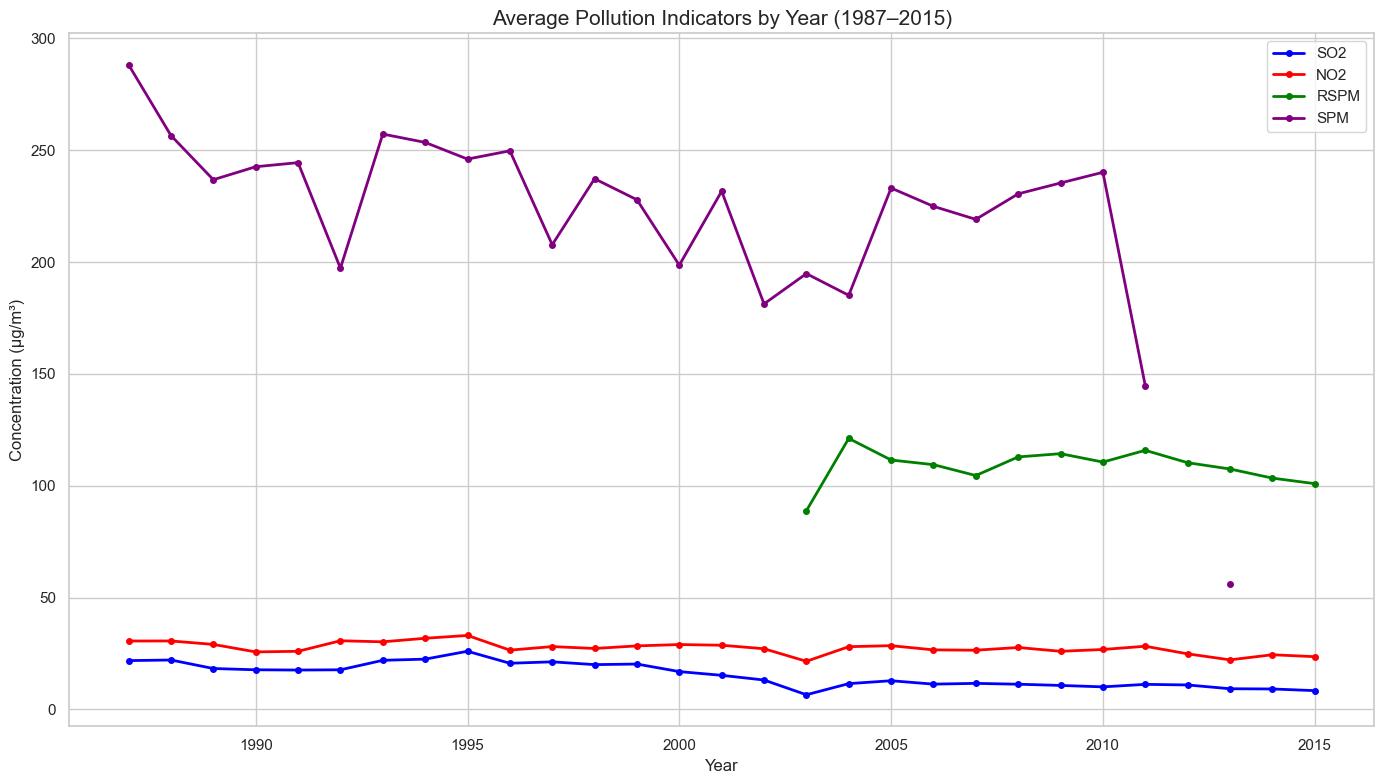

In [165]:
df["year"] = df["date"].dt.year

yearly_avg = df.groupby("year")[main_numeric_cols].mean()

fig, ax = plt.subplots(figsize=(14, 8))

colors_line = {"so2": "blue", "no2": "red", "rspm": "green", "spm": "purple"}

for col in main_numeric_cols:
    ax.plot(yearly_avg.index, yearly_avg[col], marker="o", linewidth=2,
            markersize=4, label=col.upper(), color=colors_line[col])

ax.set_title("Average Pollution Indicators by Year (1987–2015)", fontsize=15)
ax.set_xlabel("Year")
ax.set_ylabel("Concentration (µg/m³)")

ax.legend()

plt.tight_layout()

plt.show()

SPM and RSPM are consistently an order of magnitude higher than SO₂ and NO₂. The SPM decline from 280 to 140. SO₂ and NO₂ remain stable over time, with NO₂ slightly higher.

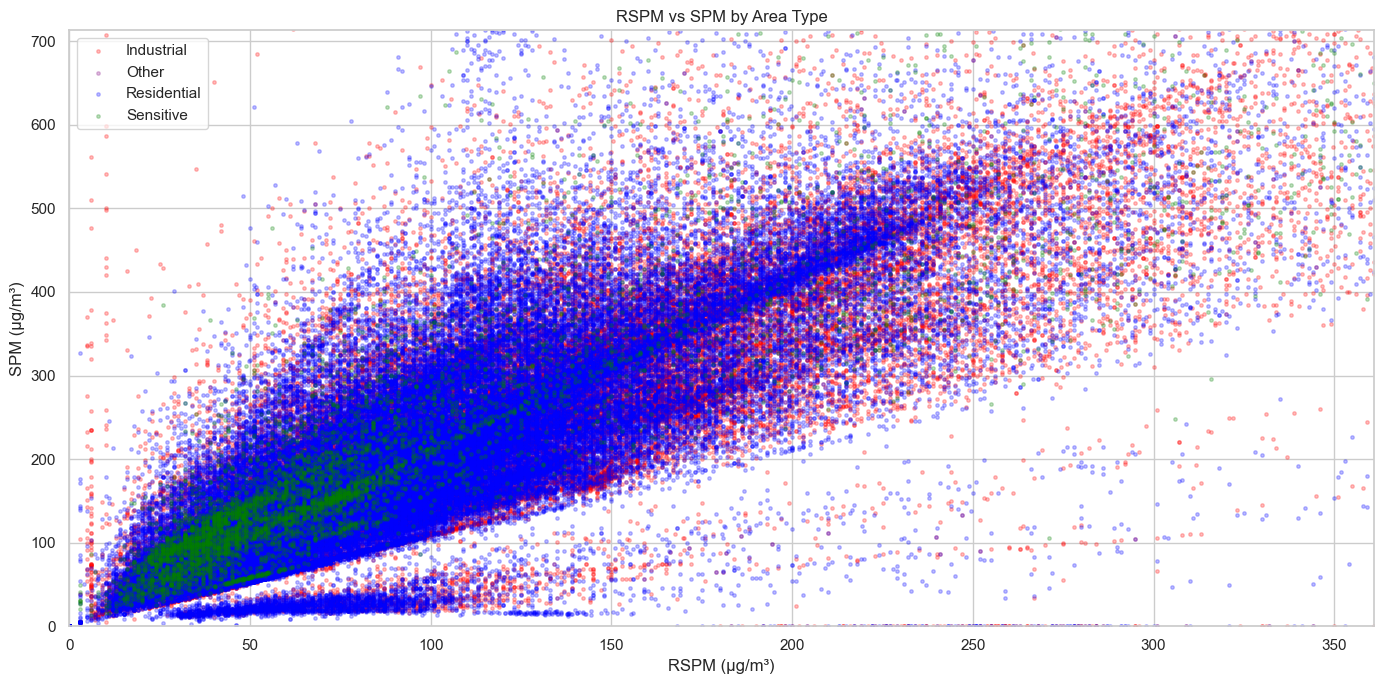

In [166]:
fig, ax = plt.subplots(figsize=(14, 7))

colors_scatter = {"Industrial": "red", "Residential": "blue", "Sensitive": "green", "Other": "purple"}

for zone, group in df.groupby("type_clean"):
    ax.scatter(
        group["rspm"], group["spm"],
        color=colors_scatter.get(zone, "gray"),
        label=zone,
        alpha=0.25,
        s=6
    )

ax.set_xlim(0, df["rspm"].quantile(0.99))
ax.set_ylim(0, df["spm"].quantile(0.99))

ax.set_title("RSPM vs SPM by Area Type")
ax.set_xlabel("RSPM (µg/m³)")
ax.set_ylabel("SPM (µg/m³)")

ax.legend()

plt.tight_layout()
plt.show()

RSPM and SPM show a clear positive correlation. Industrial zones (red) reach the highest values on both axes and show the widest spread, while residential and sensitive areas cluster at lower concentrations.

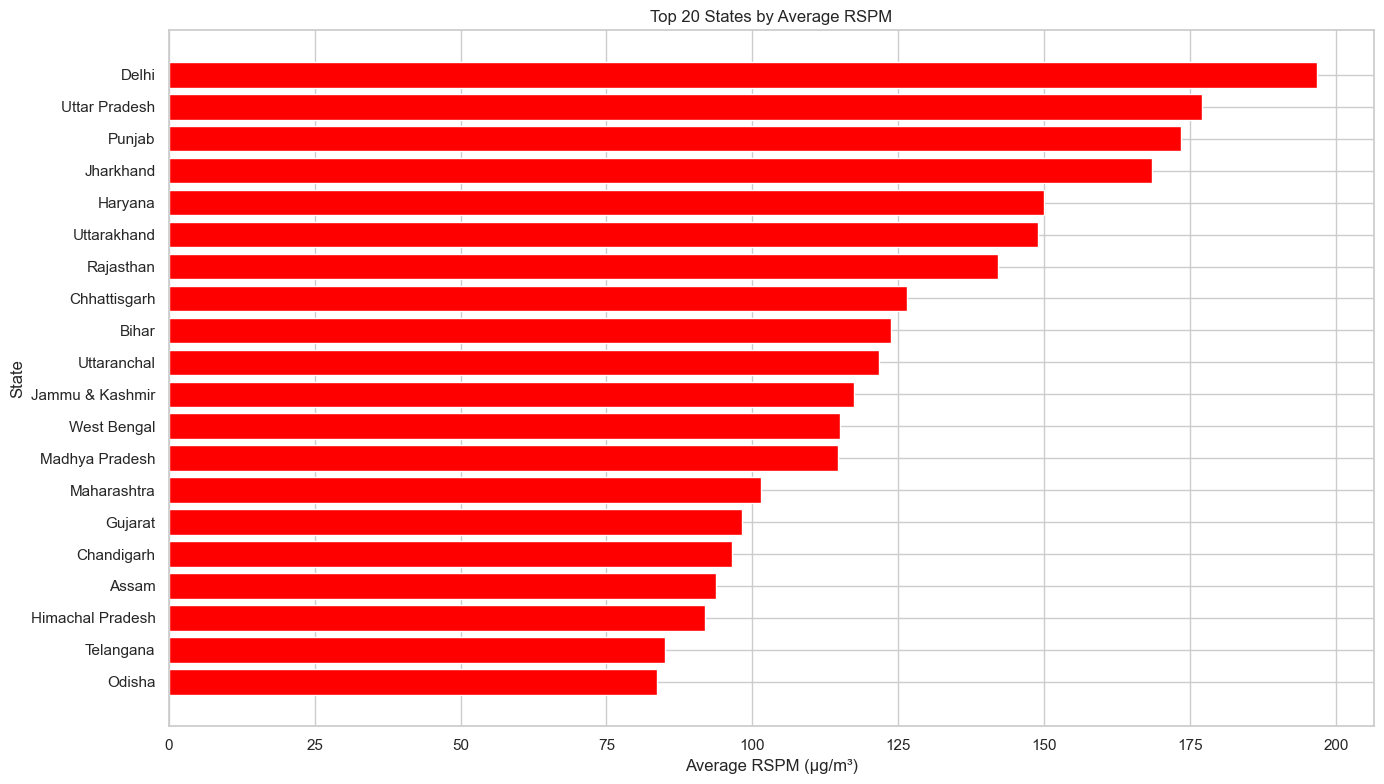

In [167]:
top_states = (
    df.groupby("state")["rspm"]
    .mean()
    .sort_values(ascending=True)
    .tail(20)
)

fig, ax = plt.subplots(figsize=(14, 8))

ax.barh(top_states.index, top_states.values, color="red")

ax.set_title("Top 20 States by Average RSPM")
ax.set_xlabel("Average RSPM (µg/m³)")
ax.set_ylabel("State")

plt.tight_layout()

plt.show()

The bar chart shows the 20 states with the highest average RSPM pollution.

## Detailed Overview

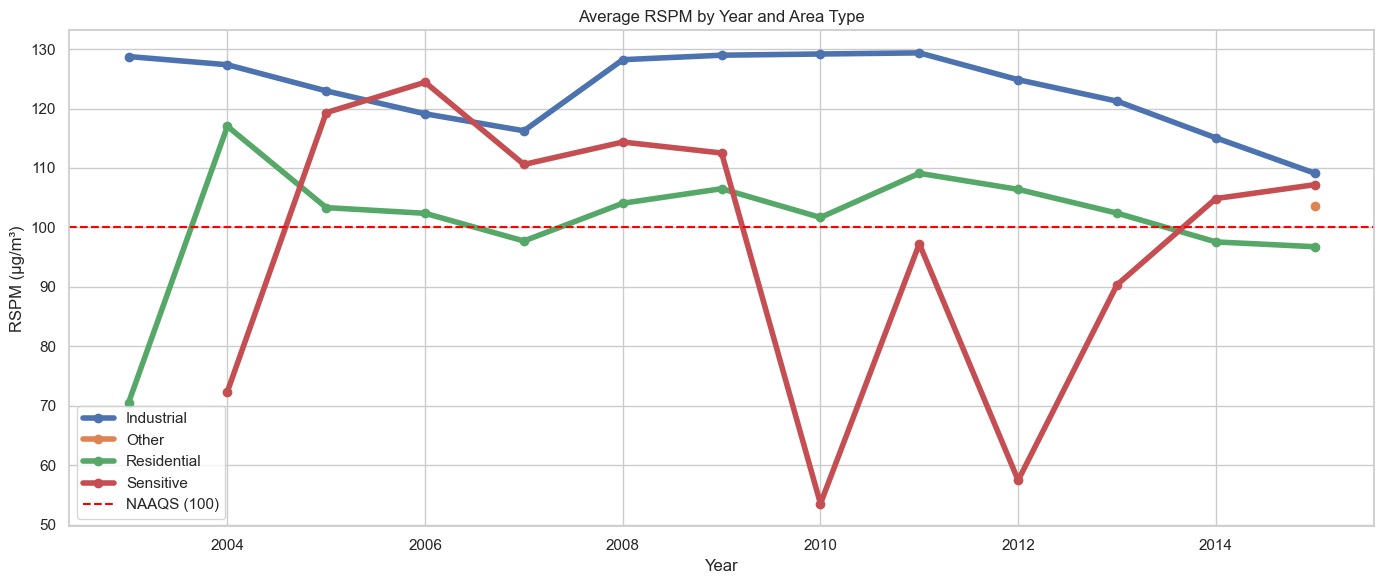

In [168]:
fig, ax = plt.subplots(figsize=(14, 6))

yearly_type = (
    df.groupby(["year", "type_clean"])["rspm"]
    .mean()
    .reset_index()
)

for zone, group in yearly_type.groupby("type_clean"):
    ax.plot(group["year"], group["rspm"], marker="o", markersize=6,
            linewidth=4, label=zone)

ax.axhline(100, color="red", linestyle="--", linewidth=1.5, label="NAAQS (100)")

ax.set_title("Average RSPM by Year and Area Type")
ax.set_xlabel("Year")
ax.set_ylabel("RSPM (µg/m³)")

ax.legend()

plt.tight_layout()

plt.show()

Industrial areas show the highest RSPM throughout the period, frequently exceeding the NAAQS limit. Residential and sensitive zones follow the same downward trend at lower levels.

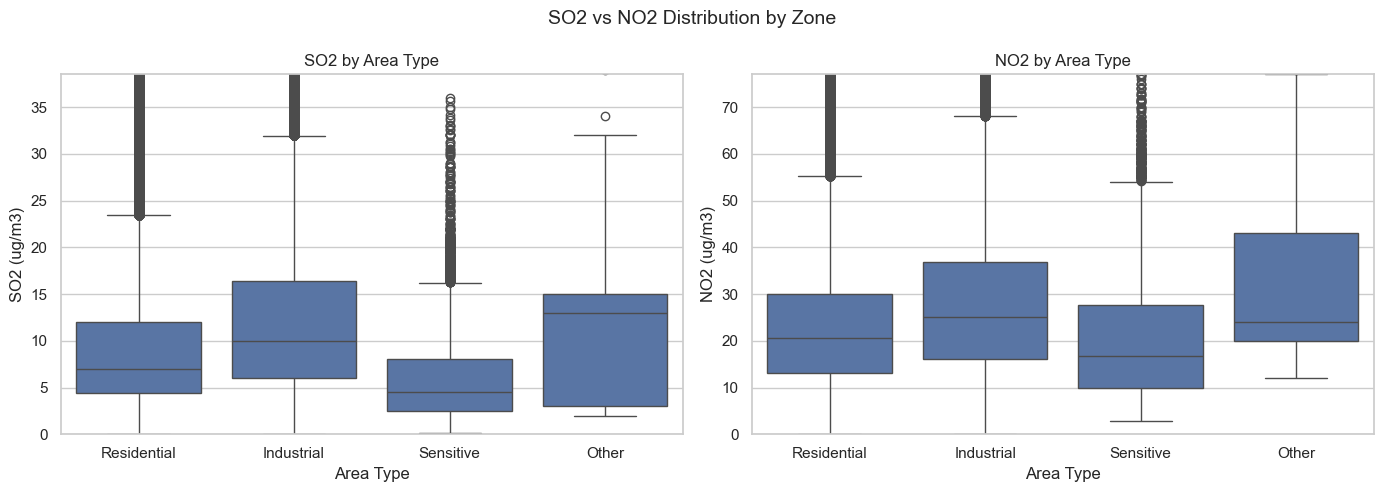

In [169]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ["so2", "no2"]):
    sns.boxplot(data=df, x="type_clean", y=col, ax=ax)
    ax.set_ylim(0, df[col].quantile(0.98))
    ax.set_title(f"{col.upper()} by Area Type")
    ax.set_xlabel("Area Type")
    ax.set_ylabel(f"{col.upper()} (ug/m3)")

plt.suptitle("SO2 vs NO2 Distribution by Zone", fontsize=14)
plt.tight_layout()
plt.show()

The side-by-side boxplots show that industrial areas consistently record higher concentrations of both SO₂ and NO₂ compared to residential and sensitive zones. The difference is more pronounced for NO₂ — industrial zones show a noticeably higher median and wider interquartile range. For SO₂, the gap between zone types is smaller.

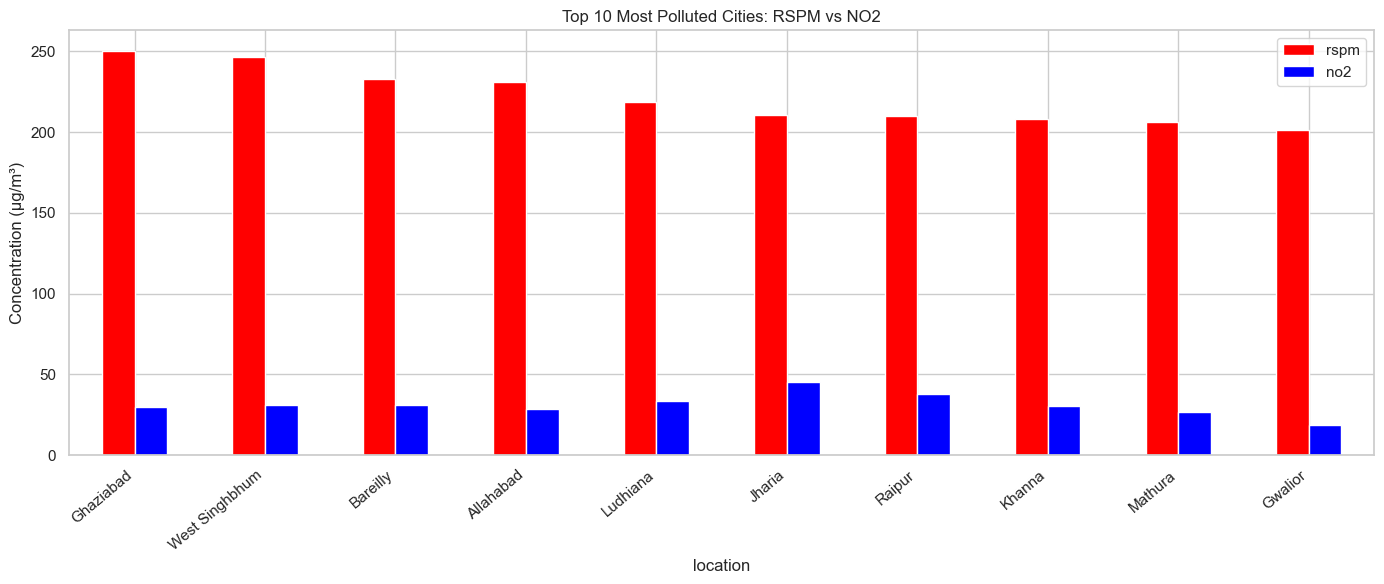

In [170]:
top10_cities = (
    df.groupby("location")["rspm"]
    .mean()
    .nlargest(10)
    .index
)

top10_df = (
    df[df["location"].isin(top10_cities)]
    .groupby("location")[["rspm", "no2"]]
    .mean()
    .sort_values("rspm", ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 6))

top10_df.plot(kind="bar", ax=ax, color=["red", "blue"])

ax.set_xticklabels(top10_df.index, rotation=40, ha="right")
ax.set_title("Top 10 Most Polluted Cities: RSPM vs NO2")
ax.set_ylabel("Concentration (µg/m³)")
ax.legend()

plt.tight_layout()
plt.show()

The top 10 most polluted cities by average RSPM are shown alongside their NO₂ levels. In all ten cities, average RSPM is substantially higher than average NO₂ in absolute terms.

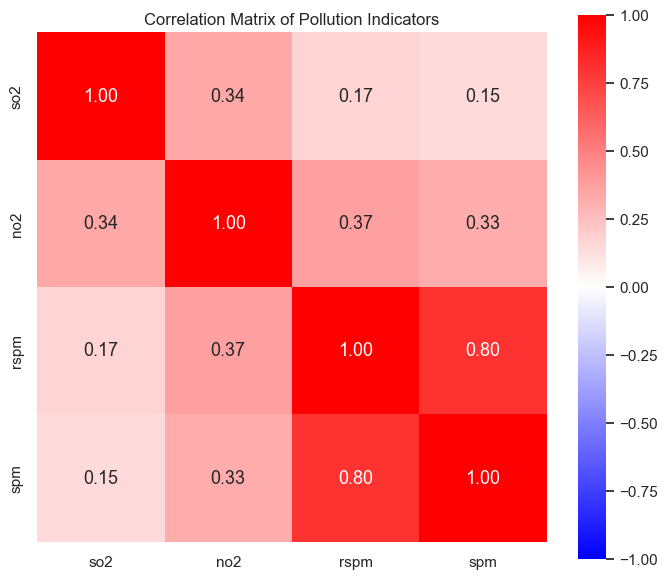

In [171]:
fig, ax = plt.subplots(figsize=(7, 6))

corr_matrix = df[main_numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="bwr",
            vmin=-1, vmax=1, square=True, ax=ax,
            annot_kws={"size": 13})

ax.set_title("Correlation Matrix of Pollution Indicators")

plt.tight_layout()
plt.show()

RSPM and SPM show the strongest mutual correlation. SO₂ and NO₂ are moderately correlated. The relationship between gaseous indicators (SO₂/NO₂) and particulate indicators (RSPM/SPM) is weaker.

## Data Transformation

Two new columns are added to the dataset:

- **`season`** — meteorological season derived from the measurement month: *Winter* (Dec–Feb), *Spring* (Mar–May), *Summer* (Jun–Aug), *Fall* (Sep–Nov).
- **`pollution_level`** — categorical label based on RSPM: *Clean* (< 60 µg/m³), *Moderate* (60–100), *Polluted* (100–200), *Severely Polluted* (> 200). RSPM is used as the base because it has the most complete coverage among all pollutant columns (~91% non-null).

In [172]:
season_map = {
    1: "Winter", 2: "Winter", 12: "Winter",
    3: "Spring", 4: "Spring",  5: "Spring",
    6: "Summer", 7: "Summer",  8: "Summer",
    9: "Fall",  10: "Fall",   11: "Fall",
}

df["season"] = df["date"].dt.month.map(season_map)

df["pollution_level"] = pd.cut(
    df["rspm"],
    bins=[0, 60, 100, 200, float("inf")],
    labels=["Clean", "Moderate", "Polluted", "Severely Polluted"],
    include_lowest=True,
)

print("Season distribution:")
print(df["season"].value_counts())
print("\nPollution level distribution:")
print(df["pollution_level"].value_counts())

Season distribution:
season
Spring    110834
Fall      107594
Summer    106992
Winter    105366
Name: count, dtype: int64

Pollution level distribution:
pollution_level
Polluted             126671
Moderate             112288
Clean                112085
Severely Polluted     43985
Name: count, dtype: int64


In [173]:
df[["date", "location", "type_clean", "rspm", "season", "pollution_level"]].head(10)

,date,location,type_clean,rspm,season,pollution_level
0,1990-02-01,Hyderabad,Residential,NaN,Winter,NaN
1,1990-02-01,Hyderabad,Industrial,NaN,Winter,NaN
2,1990-02-01,Hyderabad,Residential,NaN,Winter,NaN
3,1990-03-01,Hyderabad,Residential,NaN,Spring,NaN
4,1990-03-01,Hyderabad,Industrial,NaN,Spring,NaN
5,1990-03-01,Hyderabad,Residential,NaN,Spring,NaN
6,1990-04-01,Hyderabad,Residential,NaN,Spring,NaN
7,1990-04-01,Hyderabad,Industrial,NaN,Spring,NaN
8,1990-04-01,Hyderabad,Residential,NaN,Spring,NaN
9,1990-05-01,Hyderabad,Industrial,NaN,Spring,NaN


The `season` column groups measurements into standard meteorological seasons (Winter, Spring, Summer, Fall), making seasonal comparisons straightforward.

## Hypothesis Check

### Hypothesis 1
**NO2 levels in India show a seasonal pattern — winter months have higher average NO2 than summer months.**

To test this, monthly average NO2 is plotted separately for industrial and residential zones across the year.

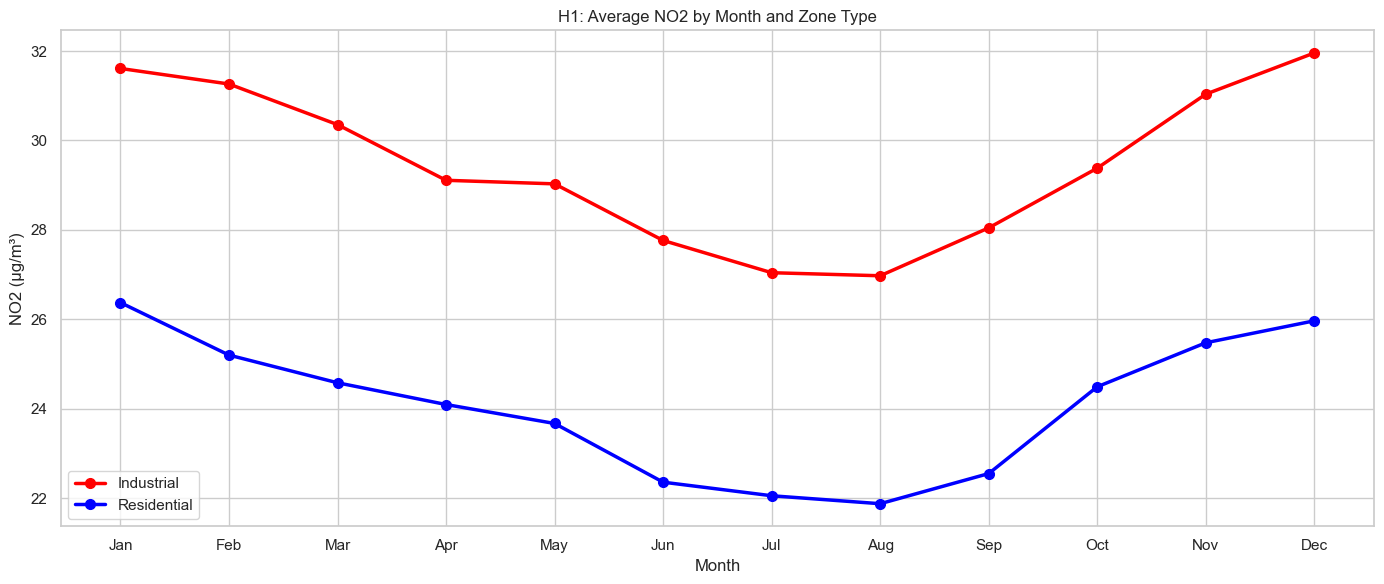

In [174]:
df["month"] = df["date"].dt.month

monthly_zone = (
    df[df["type_clean"].isin(["Industrial", "Residential"])]
    .groupby(["month", "type_clean"])["no2"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

colors_zone = {"Industrial": "red", "Residential": "blue"}

for zone, group in monthly_zone.groupby("type_clean"):
    ax.plot(group["month"], group["no2"], marker="o", linewidth=2.5,
            markersize=7, label=zone, color=colors_zone[zone])

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])

ax.set_title("H1: Average NO2 by Month and Zone Type")
ax.set_xlabel("Month")
ax.set_ylabel("NO2 (µg/m³)")
ax.legend()

plt.tight_layout()
plt.show()

**Result — Confirmed.** Both lines follow the same seasonal pattern: NO₂ peaks in the winter months and drops to its lowest point in summer. The industrial line sits consistently above the residential line throughout the entire year, but both zones show the same seasonal shape.

### Hypothesis 2
**States with higher average RSPM in industrial zones also tend to have higher average RSPM in residential zones.**

If true, a scatter plot of state-level industrial vs. residential RSPM would show a strong positive correlation. A weak correlation would suggest that the difference between zone types dominates over any state-level pattern.

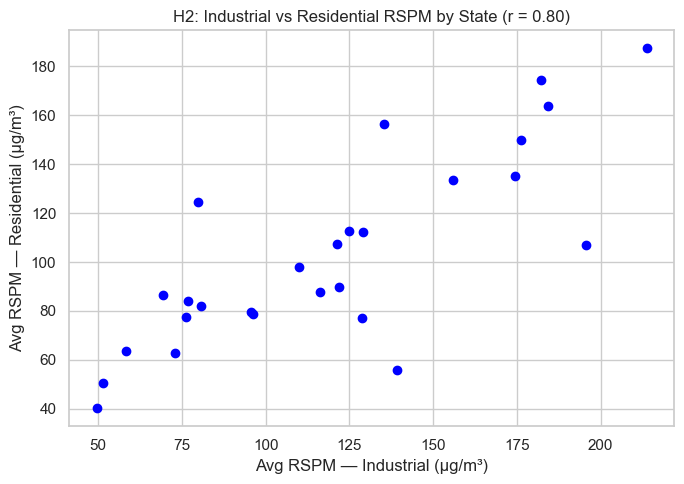

In [175]:
state_zone = (
    df[df["type_clean"].isin(["Industrial", "Residential"])]
    .groupby(["state", "type_clean"])["rspm"]
    .mean()
    .unstack()
    .dropna()
)

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(state_zone["Industrial"], state_zone["Residential"], color="blue")

ax.set_xlabel("Avg RSPM — Industrial (µg/m³)")
ax.set_ylabel("Avg RSPM — Residential (µg/m³)")

corr = state_zone["Industrial"].corr(state_zone["Residential"])
ax.set_title(f"H2: Industrial vs Residential RSPM by State (r = {corr:.2f})")

plt.tight_layout()

plt.show()

**Result — Confirmed.** The correlation between state-level industrial and residential average RSPM is **r = 0.80**, indicating a strong positive relationship. States with heavily polluted industrial zones consistently show elevated RSPM in their residential zones as well.